In [2]:
import pandas as pd
import numpy as np
import scipy.stats as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#importo il dataset
df = pd.read_csv("anime.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    10000 non-null  int64  
 1   title       10000 non-null  str    
 2   score       10000 non-null  float64
 3   rank        10000 non-null  int64  
 4   popularity  10000 non-null  int64  
 5   members     10000 non-null  int64  
 6   synopsis    9998 non-null   str    
 7   start_date  9998 non-null   str    
 8   end_date    9916 non-null   str    
 9   type        10000 non-null  str    
 10  episodes    9952 non-null   float64
 11  image_url   10000 non-null  str    
dtypes: float64(2), int64(4), str(6)
memory usage: 7.2 MB


In [4]:
df.describe()

,anime_id,score,rank,popularity,members,episodes
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,9952.000000
mean,24129.128000,6.980589,5000.494000,6490.903700,1.075309e+05,15.702271
std,19948.188153,0.619406,2886.898727,4646.309341,2.733514e+05,41.865696
min,1.000000,6.050000,1.000000,1.000000,2.260000e+02,1.000000
25%,4055.500000,6.470000,2500.750000,2591.750000,4.270250e+03,1.000000
50%,21406.000000,6.900000,5000.500000,5564.500000,1.817900e+04,11.000000
75%,40028.750000,7.390000,7500.250000,9824.250000,8.469275e+04,13.000000
max,62863.000000,9.290000,10000.000000,22184.000000,4.262220e+06,1787.000000


In [5]:
df.isnull().sum()

anime_id       0
title          0
score          0
rank           0
popularity     0
members        0
synopsis       2
start_date     2
end_date      84
type           0
episodes      48
image_url      0
dtype: int64

In [6]:
#Valuto quanti tipi ci sono e se vale la pena mantenerli per l'analisi
conteggio_formati = df['type'].value_counts()
print(conteggio_formati)

type
TV            4330
Movie         1723
ONA           1339
OVA           1172
Special       1003
TV Special     433
Name: count, dtype: int64


In [7]:
#trasformo start_date da str a datetime ed estraggo l'anno dalla data e creo una nuova collona apposita
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['year'] = df['start_date'].dt.year

#cambio il tipo della collona year per essere più preciso e di conseguenza devo eliminire le righe in cui compare il valore nullo
#faccio ciò sapendo che il numero di essi era esiguo ai fini dell'analisi
df = df.dropna(subset=['year']).copy()
df['year'] = df['year'].astype(int)

df.info()

<class 'pandas.DataFrame'>
Index: 9998 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   anime_id    9998 non-null   int64         
 1   title       9998 non-null   str           
 2   score       9998 non-null   float64       
 3   rank        9998 non-null   int64         
 4   popularity  9998 non-null   int64         
 5   members     9998 non-null   int64         
 6   synopsis    9996 non-null   str           
 7   start_date  9998 non-null   datetime64[us]
 8   end_date    9916 non-null   str           
 9   type        9998 non-null   str           
 10  episodes    9950 non-null   float64       
 11  image_url   9998 non-null   str           
 12  year        9998 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(5), str(5)
memory usage: 7.3 MB


In [8]:
#conto quanti anime sono usciti per ogni anno
conteggio_anni = df['year'].value_counts().sort_index()
print(conteggio_anni)

year
1956      1
1959      1
1960      1
1961      3
1962      1
       ... 
2021    418
2022    416
2023    474
2024    442
2025    329
Name: count, Length: 68, dtype: int64


In [9]:
df.head(10)

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url,year
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...,2015
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...,2025
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...,2011
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...,2023
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...,2011
5,15417,Gintama': Enchousen,9.02,12,756,352114,"While Gintoki Sakata was away, the Yorozuya fo...",2012-01-01,2013-01-01,TV,13.0,https://cdn.myanimelist.net/images/anime/1452/...,2012
6,39486,Gintama: The Final,9.05,7,1512,177094,Two years have passed following the Tendoshuu'...,2021-01-01,2021-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1245/...,2021
7,38524,Shingeki no Kyojin Season 3 Part 2,9.05,6,21,2520232,Seeking to restore humanity's diminishing hope...,2019-01-01,2019-01-01,TV,10.0,https://cdn.myanimelist.net/images/anime/1517/...,2019
8,34096,Gintama.,8.98,15,786,342178,After joining the resistance against the bakuf...,2017-01-01,2017-01-01,TV,12.0,https://cdn.myanimelist.net/images/anime/3/835...,2017
9,41467,Bleach: Sennen Kessen-hen,8.99,14,353,671091,Substitute Soul Reaper Ichigo Kurosaki spends ...,2022-01-01,2022-01-01,TV,13.0,https://cdn.myanimelist.net/images/anime/1908/...,2022


In [10]:
df.groupby('type').head(3)

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url,year
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...,2015
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...,2025
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...,2011
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...,2023
6,39486,Gintama: The Final,9.05,7,1512,177094,Two years have passed following the Tendoshuu'...,2021-01-01,2021-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1245/...,2021
16,820,Ginga Eiyuu Densetsu,9.02,10,753,353685,The 150-year-long stalemate between the two in...,1988-01-01,1997-01-01,OVA,110.0,https://cdn.myanimelist.net/images/anime/1976/...,1988
17,15335,Gintama Movie 2: Kanketsu-hen - Yorozuya yo Ei...,8.89,24,1058,258700,When Gintoki apprehends a movie pirate at a pr...,2013-01-01,2013-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/10/51...,2013
23,60022,One Piece Fan Letter,9.02,13,1884,135168,Although the golden age of piracy is about to ...,2024-01-01,2024-01-01,TV Special,1.0,https://cdn.myanimelist.net/images/anime/1455/...,2024
27,51535,Shingeki no Kyojin: The Final Season - Kankets...,8.86,30,261,818848,In the wake of Eren Yeager's cataclysmic actio...,2023-01-01,2023-01-01,TV Special,2.0,https://cdn.myanimelist.net/images/anime/1279/...,2023
31,35247,Owarimonogatari 2nd Season,8.86,29,602,429794,Following an encounter with oddity specialist ...,2017-01-01,2017-01-01,TV Special,7.0,https://cdn.myanimelist.net/images/anime/6/873...,2017


In [11]:
df.groupby('type').tail(3)

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url,year
9933,24645,Ai Shoujo Pollyanna Story Specials,6.06,9925,15838,774,A summary of Ai Shoujo Pollyanna Monogatari fu...,2001-01-01,2001-01-01,TV Special,2.0,https://cdn.myanimelist.net/images/anime/1963/...,2001
9951,41325,Kageyama Tamio no Double Fantasy,6.06,9940,15679,811,A 2-part TV special. The first part is a comed...,1994-01-01,1994-01-01,TV Special,1.0,https://cdn.myanimelist.net/images/anime/1523/...,1994
9954,55023,Saezuru Doubutsu wa Yarushikanai! Specials,6.06,9959,16852,619,Special episodes of Saezuru Doubutsu wa Yarush...,2020-01-01,2020-01-01,Special,5.0,https://cdn.myanimelist.net/images/anime/1246/...,2020
9960,7108,Shikabane Hime: Puchitto,6.06,9961,9380,4883,Chibi comedy released as a DVD extra.,2009-01-01,2009-01-01,Special,1.0,https://cdn.myanimelist.net/images/anime/10/16...,2009
9966,28593,Yuusha ni Narenakatta Ore wa Shibushibu Shuush...,6.06,9973,6109,14174,Specials included in the Blu-ray/DVD volumes. ...,2013-01-01,2014-01-01,Special,5.0,https://cdn.myanimelist.net/images/anime/4/690...,2013
9976,8524,The Kabocha Wine: Nita no Aijou Monogatari,6.05,9981,14751,1043,No synopsis information has been added to this...,1984-01-01,1984-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1865/...,1984
9979,8214,"Tekkamen wo Oe: ""d'Artagnan Monogatari"" yori",6.05,9980,14585,1092,Based on The Three Musketeers by Alexandre Dumas.,1987-01-01,1987-01-01,TV Special,1.0,https://cdn.myanimelist.net/images/anime/12/21...,1987
9984,51685,Zombie-ga Doeeo Beorin Naui Ttal,6.05,9992,9670,4471,One year after an unprecedented zombie attack ...,2022-01-01,2022-01-01,TV,26.0,https://cdn.myanimelist.net/images/anime/1955/...,2022
9986,204,Yumeria,6.05,9990,4553,29745,"On his 16th birthday, Tomokazu Mikuri had a re...",2004-01-01,2004-01-01,TV,12.0,https://cdn.myanimelist.net/images/anime/1135/...,2004
9990,3080,Anime Tenchou,6.05,9995,6520,12088,This is the Animation Store Manager!! Anime Te...,2002-01-01,2002-01-01,OVA,1.0,https://cdn.myanimelist.net/images/anime/1990/...,2002


In [12]:
#calcolo lo score medio per ogni tipo di distribuzione
media_per_tipo = df.groupby('type')['score'].mean()
print(media_per_tipo)

type
Movie         7.067319
ONA           6.876706
OVA           6.880923
Special       6.788544
TV            7.069148
TV Special    6.788545
Name: score, dtype: float64


In [13]:
pearson_r, p_p = sp.pearsonr(df['score'], df['members'])
print(f"Correlazione Lineare (Pearson): {pearson_r:.3f}")

Correlazione Lineare (Pearson): 0.436


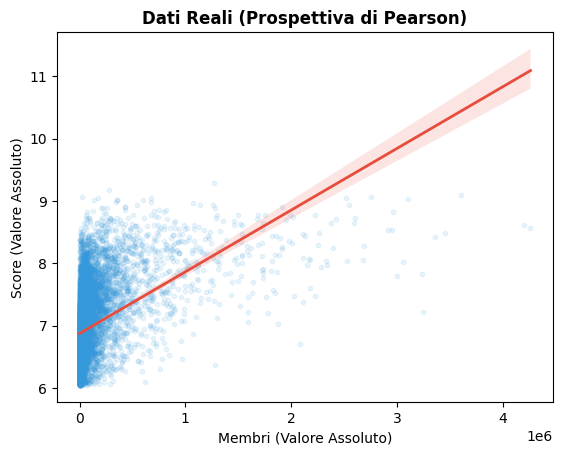

In [14]:
sns.regplot(x=df['members'], y=df['score'], 
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#3498DB'},
            line_kws={'color': '#E74C3C', 'lw': 2})
plt.title('Dati Reali (Prospettiva di Pearson)', weight='bold')
plt.xlabel('Membri (Valore Assoluto)')
plt.ylabel('Score (Valore Assoluto)')
plt.show()
plt.close()

In [15]:
#per riuscire ad utilizzare Pearson dovremmo schiacciare gli outliners per renderli gestibili
#per far ciò potremmo andare a modificare la colonna dei membri attraverso una trasformazione logaritmica
df['log10_members'] = np.log10(df['members'] + 1) 
pearson_r, p_p = sp.pearsonr(df['score'], df['log10_members'])
print(pearson_r)

0.6212964294519722


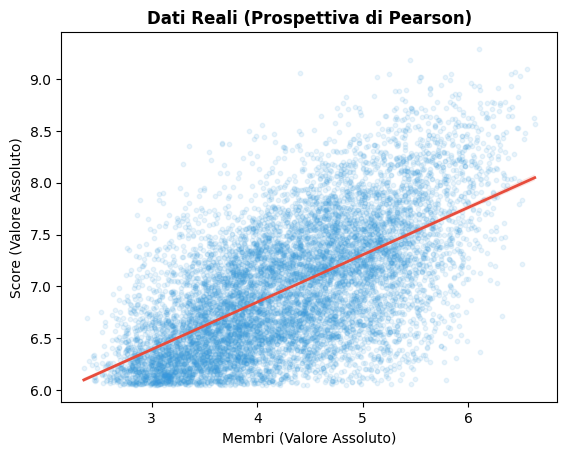

In [16]:
sns.regplot(x=df['log10_members'], y=df['score'], 
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#3498DB'},
            line_kws={'color': '#E74C3C', 'lw': 2})
plt.title('Dati Reali (Prospettiva di Pearson)', weight='bold')
plt.xlabel('Membri (Valore Assoluto)')
plt.ylabel('Score (Valore Assoluto)')
plt.show()
plt.close()

0.6103166792628851


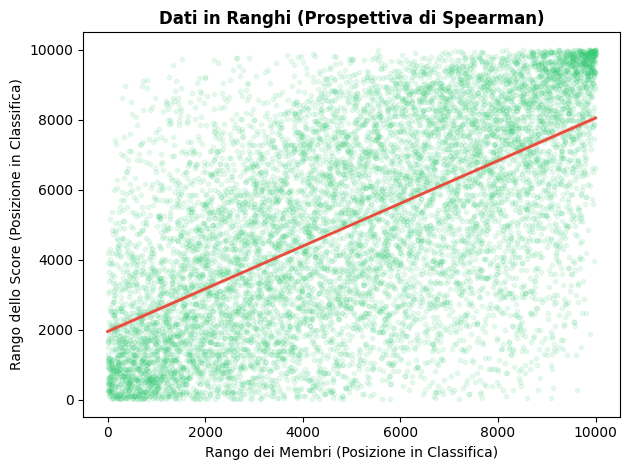

In [23]:
#calcolo Spearman
spearman_rho, p_s = sp.spearmanr(df['score'], df['members'])
print(spearman_rho)
#noto che c'è relazione fra le due colonne
#calcolo i ranghi
df['rank_score'] = df['score'].rank()
df['rank_members'] = df['members'].rank()

sns.regplot(x=df['rank_members'], y=df['rank_score'], 
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#2ECC71'},
            line_kws={'color': '#E74C3C', 'lw': 2})
plt.title('Dati in Ranghi (Prospettiva di Spearman)', weight='bold')
plt.xlabel('Rango dei Membri (Posizione in Classifica)')
plt.ylabel('Rango dello Score (Posizione in Classifica)')

plt.tight_layout()

plt.show()

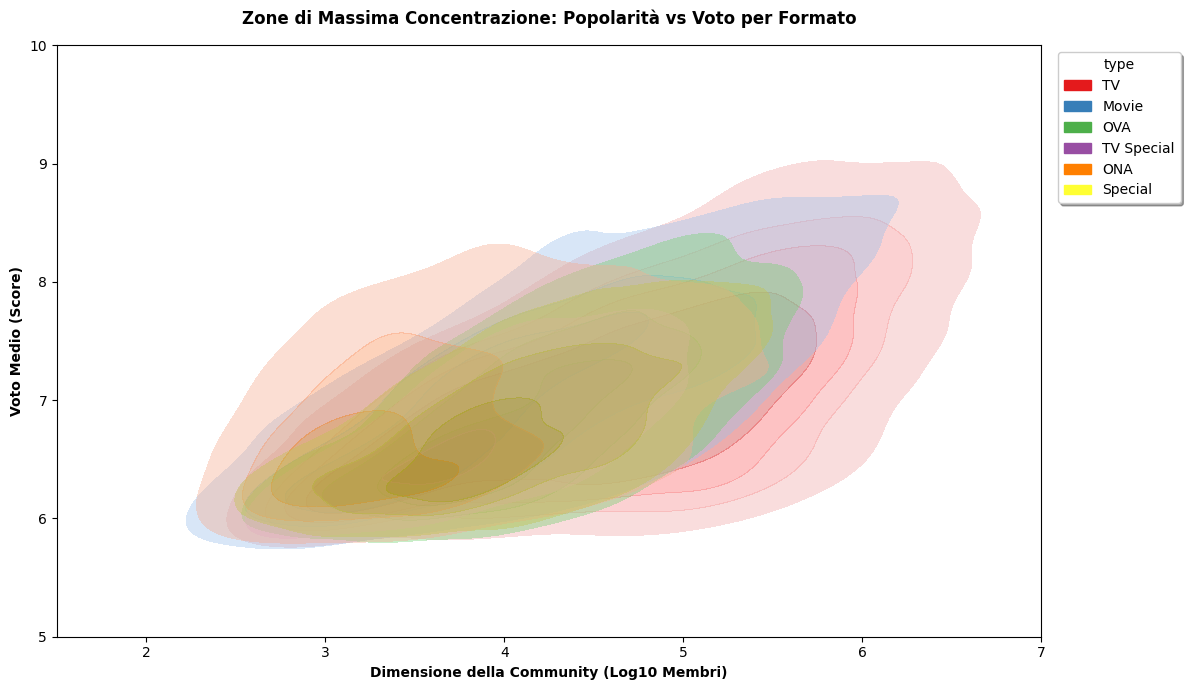

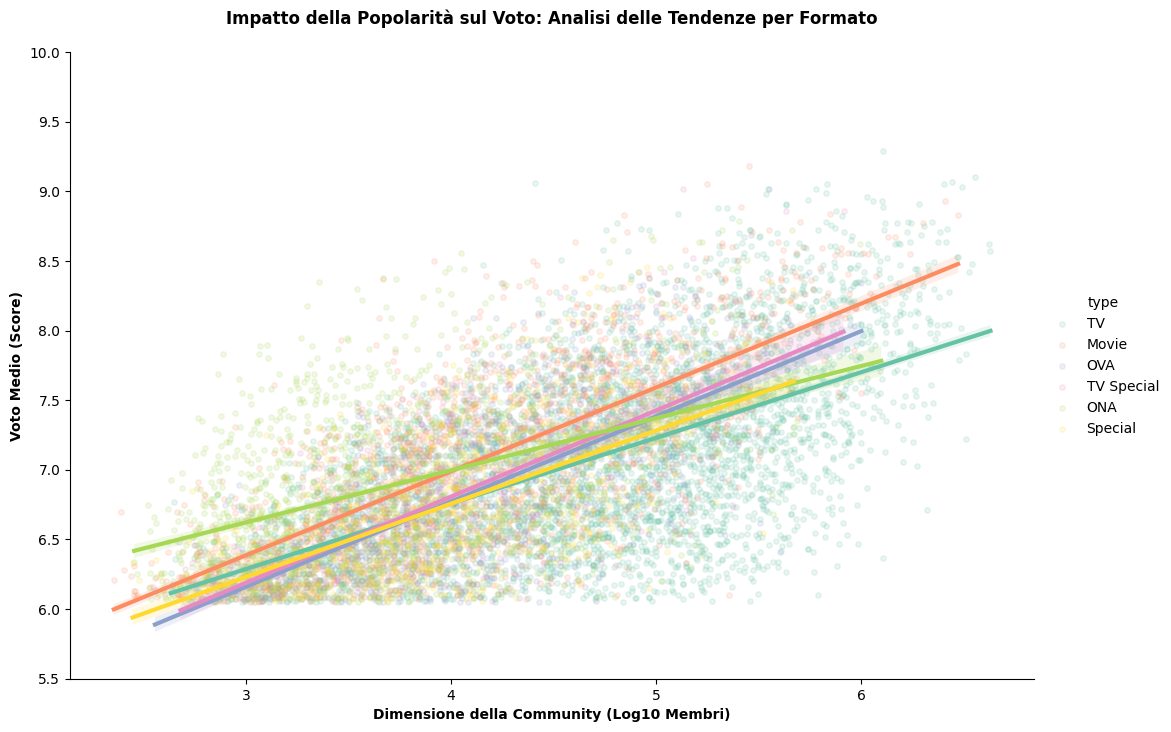

In [18]:
#vedo se possibile visualizzare in modo chiaro le posizioni dei vari canali di distribuzione nel grafico
#provo ad utilizarre altri tipi di grafico
plt.figure(figsize=(12, 7))

# Creo un grafico KDE Plot 
grafico_kde = sns.kdeplot( data=df, x='log10_members', y='score', hue='type',
                           fill=True, alpha=0.4, levels=5, palette='Set1')
plt.title('Zone di Massima Concentrazione: Popolarità vs Voto per Formato', weight='bold', pad=15)
plt.xlabel('Dimensione della Community (Log10 Membri)', weight='bold')
plt.ylabel('Voto Medio (Score)', weight='bold')
plt.ylim(5, 10) 
plt.xlim(1.5, 7)
sns.move_legend(grafico_kde, "upper left", bbox_to_anchor=(1.01, 1), frameon=True, shadow=True)

plt.tight_layout()

# Creiamo lo scatterplot colorando i punti per formato (type)
grafico_reg = sns.lmplot( data=df,  x='log10_members', y='score', hue='type',
                          height=7, aspect=1.5, palette='Set2', scatter_kws={'alpha': 0.15, 's': 15}, line_kws={'linewidth': 3})

# Personalizziamo i testi
plt.xlabel('Dimensione della Community (Log10 Membri)', weight='bold')
plt.ylabel( 'Voto Medio (Score)', weight='bold')
plt.title('Impatto della Popolarità sul Voto: Analisi delle Tendenze per Formato', weight='bold', pad=20)

plt.ylim(5.5, 10)

plt.show()

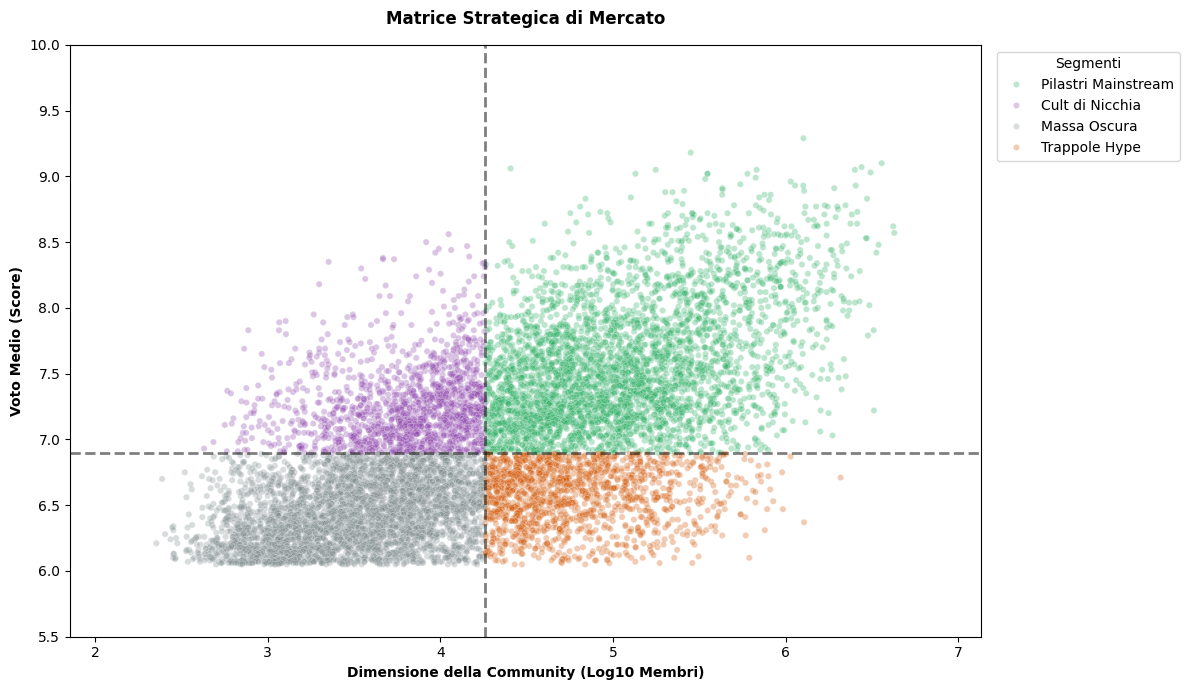

In [19]:

#calcolo la mediana
mediana_popolarita = df['log10_members'].median()
mediana_voto = df['score'].median()

#creo le 4 regole per i quadranti
condizioni = [
    (df['score'] >= mediana_voto) & (df['log10_members'] >= mediana_popolarita),
    (df['score'] >= mediana_voto) & (df['log10_members'] < mediana_popolarita),
    (df['score'] < mediana_voto) & (df['log10_members'] >= mediana_popolarita),
    (df['score'] < mediana_voto) & (df['log10_members'] < mediana_popolarita)
]

#do un nome da associare a ogni valore
nomi_quadranti = [
    'Pilastri Mainstream',
    'Cult di Nicchia',
    'Trappole Hype',
    'Massa Oscura'
]
#applico le regole e creo una nuova colonna nel dataset
df['segmento_mercato'] = np.select(condizioni, nomi_quadranti, default='Sconosciuto')

#grafico
plt.figure(figsize=(12, 7))

grafico = sns.scatterplot( data=df, x='log10_members', y='score', hue='segmento_mercato',
                           palette={ 
                                'Pilastri Mainstream': '#27ae60', # Verde
                                'Cult di Nicchia': '#8e44ad',     # Viola
                                'Trappole Hype': '#d35400',       # Arancione
                                'Massa Oscura': '#7f8c8d'         # Grigio
                           }, alpha=0.3, s=20 )

#aggiungo le mediane
plt.axvline(mediana_popolarita, color='black', linestyle='--', linewidth=2, alpha=0.5)
plt.axhline(mediana_voto, color='black', linestyle='--', linewidth=2, alpha=0.5)

#metto il titolo e gli assi
plt.title('Matrice Strategica di Mercato', weight='bold', pad=15)
plt.xlabel('Dimensione della Community (Log10 Membri)', weight='bold')
plt.ylabel('Voto Medio (Score)', weight='bold')

#leggenda
sns.move_legend(grafico, "upper left", bbox_to_anchor=(1.01, 1), frameon=True, title='Segmenti')

#ottimizzo lo spazio 
plt.ylim(5.5, 10) 
plt.xlim(df['log10_members'].min() - 0.5, df['log10_members'].max() + 0.5)

plt.tight_layout()
plt.show()

In [20]:
df.to_pickle("10KAnime.pickle")